# Introduction to Regression Techniques

Regression techniques form a cornerstone of both classical statistics and modern data science. At their core, these methods aim to model the relationship between one or more independent variables (predictors) and a dependent variable (outcome). This enables us to make predictions, understand associations, and even infer causal relationships under certain conditions.

## Key Aspects of Regression Techniques

- **Purpose and Utility**: Regression analysis quantifies how the dependent variable changes when any one of the independent variables is varied while keeping others constant. It is widely used in fields such as economics, medicine, engineering, and social sciences.
- **Modeling the Relationship**: The simplest form (*linear regression*) assumes a linear relationship. More advanced models (e.g., polynomial, logistic, or nonparametric regression) allow for modeling nonlinearities and more complex data structures.
- **Assumptions**: Common assumptions include linearity (or appropriate transformations), independence of errors, homoscedasticity, and (for inference) normality of errors.
- **Loss Functions and Optimization**: Most methods minimize a loss function (e.g., mean squared error, logistic loss) via optimization algorithms ranging from closed-form solutions to iterative methods.
- **Regularization and Overfitting**: Techniques such as Ridge, Lasso, and Elastic Net add penalties to mitigate overfitting, particularly in high-dimensional settings or when multicollinearity is present.
- **Evaluation and Diagnostics**: Model performance is commonly assessed using goodness-of-fit metrics (e.g., R-squared, RMSE), residual analysis, and likelihood-based criteria (e.g., AIC, BIC).
- **Applicability and Robustness**: Different regression methods offer trade-offs regarding robustness to outliers, sensitivity to multicollinearity, heteroscedasticity, and the ability to handle high-dimensional or non-normal data, as well as time-series data.

#### Initialization

In [1]:
import scipy.sparse

# Add an 'A' property to csr_matrix so that A returns the dense array
if not hasattr(scipy.sparse.csr_matrix, "A"):
    scipy.sparse.csr_matrix.A = property(lambda self: self.toarray())

In [2]:
# Import common libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# For splitting data and evaluating model performance
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Set a consistent style for plots
plt.style.use('default')

## 1. Linear Regression (Simple) – From Scratch

In this section, we create synthetic data for a simple linear regression with one predictor and implement the solution using the **Normal Equation**.

**Assumptions**: Linear relationship, independence of errors, constant variance, normally distributed errors (for inference).
**Formula**: $y = \theta_0 + \theta_1 x$.
**Loss Function**: Mean Squared Error (MSE).
**Likelihood Function**: Gaussian likelihood when errors are normally distributed.
**Goodness-of-Fit Metrics**: R-squared, RMSE.
**Residual Analysis**: Check for randomness, constant variance, and normality of residuals.
**Overfitting Risk**: Low for one predictor; increases with model complexity.
**Convergence Speed**: Instantaneous (closed-form solution).
**Optimization Algorithm Used**: Direct matrix inversion (Normal Equation).
**Handling of Outliers**: Sensitive; outliers can skew results.
**Sensitivity to Multicollinearity**: Not applicable (single predictor).
**Sensitivity to Heteroscedasticity**: Sensitive; heteroscedastic errors can bias estimates.
**Applicability to High-Dimensional Data**: Not applicable for a single predictor.
**Robustness to Non-Normal Data**: Limited; inference may be affected.
**Time-Series Applicability**: Not directly applicable without accounting for autocorrelation.


Optimal parameters (theta): [4.22215108 2.96846751]


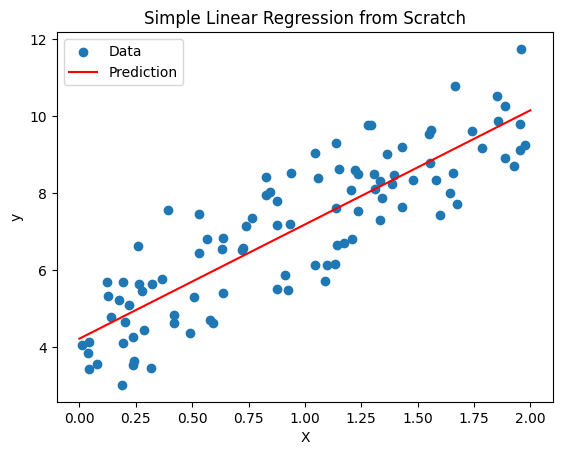

In [3]:
# Set seed for reproducibility
np.random.seed(0)

# Generate synthetic data: 100 random samples for a single feature X
X = 2 * np.random.rand(100, 1)

# Create target variable y with an intercept of 4 and slope of 3, plus some noise
y = 4 + 3 * X[:, 0] + np.random.randn(100)

# Add bias term (x0 = 1) to each sample for the intercept
X_b = np.c_[np.ones((100, 1)), X]

# Compute the optimal theta using the Normal Equation
theta_best = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)
print("Optimal parameters (theta):", theta_best)

# Plot the original data and the regression line
plt.scatter(X, y, label="Data")
X_new = np.array([[0], [2]])
X_new_b = np.c_[np.ones((2, 1)), X_new]
y_predict = X_new_b.dot(theta_best)
plt.plot(X_new, y_predict, color="red", label="Prediction")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.title("Simple Linear Regression from Scratch")
plt.show()

## 2. Multiple Linear Regression

We generate synthetic data with three predictors and use scikit-learn’s `LinearRegression` to fit a multiple linear regression model.

**Assumptions**: Linearity in parameters, independence, homoscedasticity, normality of errors.
**Formula**: $y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \beta_3 x_3$.
**Loss Function**: Mean Squared Error (MSE).
**Likelihood Function**: Gaussian likelihood under normal error assumption.
**Goodness-of-Fit Metrics**: R-squared, Adjusted R-squared.
**Residual Analysis**: Check for independence and constant variance.
**Overfitting Risk**: Increases with more predictors if not regularized.
**Convergence Speed**: Fast using analytical or iterative solvers.
**Optimization Algorithm Used**: Typically solved via least squares.
**Handling of Outliers**: Can be sensitive; outliers may unduly influence the model.
**Sensitivity to Multicollinearity**: High if predictors are highly correlated.
**Sensitivity to Heteroscedasticity**: May affect standard errors.
**Applicability to High-Dimensional Data**: Limited without regularization.
**Robustness to Non-Normal Data**: Moderate for prediction but affects inference.
**Time-Series Applicability**: Requires adjustments for autocorrelation.


In [4]:
from sklearn.linear_model import LinearRegression

# Generate synthetic data with 3 predictors
np.random.seed(0)
X_multi = 2 * np.random.rand(100, 3)
y_multi = 1 + 2 * X_multi[:, 0] + 3 * X_multi[:, 1] + 4 * X_multi[:, 2] + np.random.randn(100)

# Fit the multiple linear regression model
lr = LinearRegression()
lr.fit(X_multi, y_multi)
print("Intercept:", lr.intercept_)
print("Coefficients:", lr.coef_)


Intercept: 0.9502139024683576
Coefficients: [1.79566239 2.98997832 4.12661549]


## 3. Polynomial Regression

We use scikit-learn's `PolynomialFeatures` to extend a linear model by including polynomial terms.

**Assumptions**: The underlying relationship can be approximated by a polynomial.
**Formula**: For degree 2: $y = \beta_0 + \beta_1 x + \beta_2 x^2$.
**Loss Function**: Mean Squared Error (MSE).
**Likelihood Function**: Gaussian likelihood if errors are normal.
**Goodness-of-Fit Metrics**: R-squared, RMSE.
**Residual Analysis**: Check for patterns; residuals should be random.
**Overfitting Risk**: High if the polynomial degree is too large relative to data points.
**Convergence Speed**: Fast with analytical solutions.
**Optimization Algorithm Used**: Linear least squares on transformed features.
**Handling of Outliers**: Can be sensitive if extreme values drive the fit.
**Sensitivity to Multicollinearity**: High if polynomial terms are highly correlated.
**Sensitivity to Heteroscedasticity**: Similar to linear regression.
**Applicability to High-Dimensional Data**: Typically used for univariate data; multivariate extensions are possible but challenging.
**Robustness to Non-Normal Data**: Moderate; non-normal errors affect inference.
**Time-Series Applicability**: Can be applied, but serial correlation should be considered.


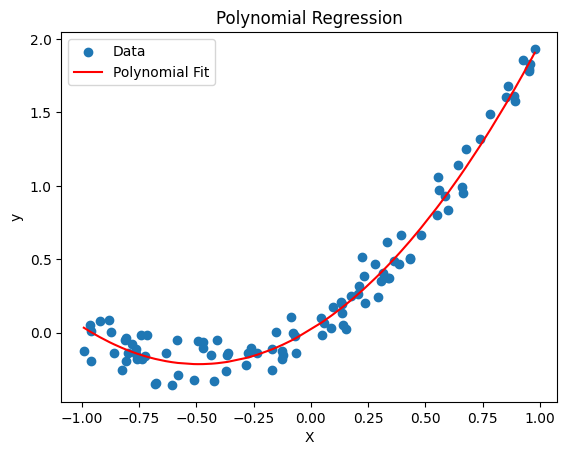

In [5]:
from sklearn.preprocessing import PolynomialFeatures

# Generate synthetic data for polynomial regression
np.random.seed(0)
X_poly = np.sort(2 * np.random.rand(100, 1) - 1, axis=0)
y_poly = X_poly[:, 0]**2 + X_poly[:, 0] + np.random.randn(100) * 0.1

# Transform to polynomial features
poly = PolynomialFeatures(degree=2)
X_poly_transformed = poly.fit_transform(X_poly)

# Fit linear regression on the transformed features
lr_poly = LinearRegression()
lr_poly.fit(X_poly_transformed, y_poly)

# Plot the data and the polynomial fit
plt.scatter(X_poly, y_poly, label="Data")
plt.plot(X_poly, lr_poly.predict(X_poly_transformed), color="red", label="Polynomial Fit")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.title("Polynomial Regression")
plt.show()

## 4. Logistic Regression (Binary)

We generate synthetic binary data and fit a logistic regression model using scikit-learn.

**Assumptions**: The logit of the probability is linearly related to predictors; observations are independent.
**Formula**: $\log \left( \frac{p}{1-p} \right) = \beta_0 + \beta_1 x_1 + \cdots$.
**Loss Function**: Logistic (cross-entropy) loss.
**Likelihood Function**: Bernoulli likelihood for binary outcomes.
**Goodness-of-Fit Metrics**: Accuracy, AUC, log-loss.
**Residual Analysis**: Deviance residuals are examined.
**Overfitting Risk**: Can be mitigated by regularization.
**Convergence Speed**: Typically fast with iterative solvers (e.g., Newton–Raphson).
**Optimization Algorithm Used**: Iteratively reweighted least squares or gradient descent.
**Handling of Outliers**: Sensitive if influential points exist.
**Sensitivity to Multicollinearity**: High; can affect coefficient stability.
**Sensitivity to Heteroscedasticity**: Not applicable in the same way as OLS.
**Applicability to High-Dimensional Data**: Often requires regularization (e.g., L1, L2 penalties).
**Robustness to Non-Normal Data**: Direct modeling of the binary outcome bypasses normality assumptions.
**Time-Series Applicability**: Extensions exist (e.g., logistic autoregression) for time-series data.


In [6]:
from sklearn.linear_model import LogisticRegression

np.random.seed(0)
X_log = np.random.randn(100, 2)
y_log = (X_log[:, 0] + X_log[:, 1] > 0).astype(int)

log_reg = LogisticRegression()
log_reg.fit(X_log, y_log)

print("Intercept:", log_reg.intercept_)
print("Coefficients:", log_reg.coef_)


Intercept: [-0.01934518]
Coefficients: [[2.82885458 2.58875509]]


## 5. Ordinal Regression

Ordinal regression models outcomes with a natural order. Here we use the `mord` package.

**Assumptions**: Assumes an ordered relationship between outcome categories.
**Formula**: Similar to logistic regression but with cumulative odds.
**Loss Function**: Typically a logistic loss modified for ordinal data.
**Likelihood Function**: Based on cumulative probabilities.
**Goodness-of-Fit Metrics**: Pseudo R-squared, AIC.
**Residual Analysis**: Examine residuals based on predicted ordinal categories.
**Overfitting Risk**: Moderate if too many predictors are included.
**Convergence Speed**: Reasonable with iterative solvers.
**Optimization Algorithm Used**: Maximum likelihood estimation with iterative methods.
**Handling of Outliers**: Outliers are less influential due to categorization.
**Sensitivity to Multicollinearity**: Can be an issue with highly correlated predictors.
**Sensitivity to Heteroscedasticity**: Not a primary concern.
**Applicability to High-Dimensional Data**: Best used when the number of predictors is limited.
**Robustness to Non-Normal Data**: Robust due to use of ordinal categories.
**Time-Series Applicability**: Typically not used for time-series data.


In [7]:
import mord

np.random.seed(0)
X_ord = np.random.randn(100, 2)
y_ord = np.digitize(X_ord[:, 0] + X_ord[:, 1] + np.random.randn(100) * 0.5, bins=[-0.5, 0.5])

ord_reg = mord.LogisticAT()
ord_reg.fit(X_ord, y_ord)
print("Ordinal Regression Coefficients:", ord_reg.coef_)


Ordinal Regression Coefficients: [2.59064424 2.41024966]


## 6. Multinomial Logistic Regression

We use the Iris dataset to fit a multinomial logistic regression model, which handles more than two outcome categories.

**Assumptions**: Similar to binary logistic regression, but for multiple classes.
**Formula**: Uses the softmax function: $p(y=i|x)=\frac{e^{\beta_i^T x}}{\sum_{j} e^{\beta_j^T x}}$.
**Loss Function**: Cross-entropy loss.
**Likelihood Function**: Multinomial likelihood.
**Goodness-of-Fit Metrics**: Accuracy, confusion matrix, log-loss.
**Residual Analysis**: Examine misclassification and deviance residuals.
**Overfitting Risk**: Mitigated with regularization and proper model selection.
**Convergence Speed**: Fast with modern solvers (e.g., LBFGS).
**Optimization Algorithm Used**: Iterative optimization (e.g., Newton–Raphson, gradient descent).
**Handling of Outliers**: Sensitive to extreme values unless regularized.
**Sensitivity to Multicollinearity**: High if predictors are correlated; regularization helps.
**Sensitivity to Heteroscedasticity**: Not directly applicable.
**Applicability to High-Dimensional Data**: Often requires regularization.
**Robustness to Non-Normal Data**: Handles categorical outcomes directly.
**Time-Series Applicability**: Extensions exist for time-series classification.


In [8]:
from sklearn.datasets import load_iris

iris = load_iris()
X_iris, y_iris = iris.data, iris.target

multi_log_reg = LogisticRegression(solver='lbfgs', max_iter=200)
multi_log_reg.fit(X_iris, y_iris)
print("Multinomial Logistic Regression Coefficients:\n", multi_log_reg.coef_)


Multinomial Logistic Regression Coefficients:
 [[-0.42468213  0.96714132 -2.51552827 -1.08228622]
 [ 0.53509422 -0.32079311 -0.20713148 -0.94316337]
 [-0.11041209 -0.64634822  2.72265975  2.02544959]]


## 7. Ridge Regression

We use Ridge regression (L2 regularization) to penalize large coefficients and reduce overfitting.

**Assumptions**: Similar to OLS but with a penalty; assumes linearity.
**Formula**: $\min_{\beta} \|y - X\beta\|^2 + \alpha \|\beta\|^2$.
**Loss Function**: Squared error plus L2 penalty.
**Likelihood Function**: Gaussian likelihood with regularization.
**Goodness-of-Fit Metrics**: R-squared, RMSE.
**Residual Analysis**: As with OLS but with regularized estimates.
**Overfitting Risk**: Reduced relative to OLS.
**Convergence Speed**: Fast (closed-form solution or efficient iterative solvers).
**Optimization Algorithm Used**: Analytical solution or gradient descent.
**Handling of Outliers**: Not specifically robust.
**Sensitivity to Multicollinearity**: Helps mitigate multicollinearity.
**Sensitivity to Heteroscedasticity**: Similar to OLS.
**Applicability to High-Dimensional Data**: More stable than OLS when predictors outnumber observations.
**Robustness to Non-Normal Data**: Moderate.
**Time-Series Applicability**: Applicable, though autocorrelation should be addressed separately.


In [9]:
from sklearn.linear_model import Ridge

np.random.seed(0)
X_ridge = 2 * np.random.rand(100, 3)
y_ridge = 1 + 2 * X_ridge[:, 0] + 3 * X_ridge[:, 1] + 4 * X_ridge[:, 2] + np.random.randn(100)

ridge = Ridge(alpha=1.0)
ridge.fit(X_ridge, y_ridge)
print("Ridge Regression Coefficients:", ridge.coef_)


Ridge Regression Coefficients: [1.76476693 2.8941159  3.99527028]


## 8. Lasso Regression

Lasso regression uses L1 regularization which can shrink some coefficients to zero, performing variable selection.

**Assumptions**: Similar to OLS with the added assumption that some predictors have zero effect.
**Formula**: $\min_{\beta} \|y - X\beta\|^2 + \alpha \|\beta\|_1$.
**Loss Function**: Squared error plus L1 penalty.
**Likelihood Function**: Gaussian likelihood with L1 regularization.
**Goodness-of-Fit Metrics**: R-squared, RMSE, cross-validation error.
**Residual Analysis**: Similar to OLS but with sparse estimates.
**Overfitting Risk**: Reduced by variable selection.
**Convergence Speed**: Typically fast with coordinate descent.
**Optimization Algorithm Used**: Coordinate descent.
**Handling of Outliers**: Not robust by itself.
**Sensitivity to Multicollinearity**: May arbitrarily select one predictor among correlated ones.
**Sensitivity to Heteroscedasticity**: As with OLS.
**Applicability to High-Dimensional Data**: Often used when the number of predictors is large.
**Robustness to Non-Normal Data**: Moderate.
**Time-Series Applicability**: Applicable with caution on autocorrelated errors.


In [10]:
from sklearn.linear_model import Lasso

np.random.seed(0)
X_lasso = 2 * np.random.rand(100, 3)
y_lasso = 1 + 2 * X_lasso[:, 0] + 3 * X_lasso[:, 1] + 4 * X_lasso[:, 2] + np.random.randn(100)

lasso = Lasso(alpha=0.1)
lasso.fit(X_lasso, y_lasso)
print("Lasso Regression Coefficients:", lasso.coef_)


Lasso Regression Coefficients: [1.55758868 2.67217244 3.81596824]


## 9. Elastic Net Regression

Elastic Net combines L1 and L2 penalties to balance between Ridge and Lasso.

**Assumptions**: Same as linear regression with the assumption that some coefficients may be zero while others are shrunk.
**Formula**: $\min_{\beta} \|y - X\beta\|^2 + \alpha (\lambda \|\beta\|_1 + (1-\lambda) \|\beta\|^2)$.
**Loss Function**: Squared error plus a combination of L1 and L2 penalties.
**Likelihood Function**: Gaussian likelihood with mixed regularization.
**Goodness-of-Fit Metrics**: R-squared, RMSE, cross-validation error.
**Residual Analysis**: Similar to OLS with regularized estimates.
**Overfitting Risk**: Reduced by the penalty term.
**Convergence Speed**: Similar to Lasso; typically solved by coordinate descent.
**Optimization Algorithm Used**: Coordinate descent.
**Handling of Outliers**: Not specifically robust.
**Sensitivity to Multicollinearity**: Better than Lasso alone; the ridge component helps.
**Sensitivity to Heteroscedasticity**: As with OLS.
**Applicability to High-Dimensional Data**: Often used in high-dimensional settings.
**Robustness to Non-Normal Data**: Moderate.
**Time-Series Applicability**: Applicable with proper preprocessing.


In [11]:
from sklearn.linear_model import ElasticNet

np.random.seed(0)
X_elastic = 2 * np.random.rand(100, 3)
y_elastic = 1 + 2 * X_elastic[:, 0] + 3 * X_elastic[:, 1] + 4 * X_elastic[:, 2] + np.random.randn(100)

elastic = ElasticNet(alpha=0.1, l1_ratio=0.5)
elastic.fit(X_elastic, y_elastic)
print("Elastic Net Regression Coefficients:", elastic.coef_)


Elastic Net Regression Coefficients: [1.53980806 2.42825028 3.41184653]


## 10. Stepwise Regression

We perform forward selection (stepwise regression) using AIC as a selection criterion via statsmodels.

**Assumptions**: As with OLS; assumes that adding predictors improves the model if justified by AIC.
**Formula**: Iteratively builds a model: $y = \beta_0 + \beta_1 x_{1} + \cdots$.
**Loss Function**: Mean Squared Error combined with AIC as a model selection metric.
**Likelihood Function**: Gaussian likelihood.
**Goodness-of-Fit Metrics**: AIC, BIC, R-squared.
**Residual Analysis**: Standard OLS residual analysis.
**Overfitting Risk**: Controlled by the AIC penalty.
**Convergence Speed**: Moderate; depends on the number of predictors.
**Optimization Algorithm Used**: Greedy algorithm adding predictors one-by-one.
**Handling of Outliers**: Inherits sensitivity from OLS.
**Sensitivity to Multicollinearity**: Can be affected if correlated predictors are considered.
**Sensitivity to Heteroscedasticity**: As with OLS.
**Applicability to High-Dimensional Data**: Limited by computational cost.
**Robustness to Non-Normal Data**: As with OLS.
**Time-Series Applicability**: Not directly applicable without modifications.


In [12]:
import statsmodels.api as sm

def forward_selection(data, response):
    """
    Perform forward selection based on AIC.
    """
    remaining = set(data.columns)
    remaining.remove(response)
    selected = []
    current_score, best_new_score = float('inf'), float('inf')
    while remaining:
        scores_with_candidates = []
        for candidate in remaining:
            formula = "{} ~ {}".format(response, " + ".join(selected + [candidate]))
            model = sm.OLS.from_formula(formula, data).fit()
            aic = model.aic
            scores_with_candidates.append((aic, candidate))
        scores_with_candidates.sort()
        best_new_score, best_candidate = scores_with_candidates[0]
        if current_score > best_new_score:
            remaining.remove(best_candidate)
            selected.append(best_candidate)
            current_score = best_new_score
        else:
            break
    formula = "{} ~ {}".format(response, " + ".join(selected))
    model = sm.OLS.from_formula(formula, data).fit()
    return model

np.random.seed(0)
df_step = pd.DataFrame({
    'X1': np.random.randn(100),
    'X2': np.random.randn(100),
    'X3': np.random.randn(100),
    'X4': np.random.randn(100)
})
df_step['y'] = 1 + 2 * df_step['X1'] + 0 * df_step['X2'] + 3 * df_step['X3'] + np.random.randn(100)

model_fs = forward_selection(df_step, 'y')
print(model_fs.summary())


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.927
Model:                            OLS   Adj. R-squared:                  0.926
Method:                 Least Squares   F-statistic:                     618.4
Date:                Sun, 15 Mar 2026   Prob (F-statistic):           6.20e-56
Time:                        22:36:23   Log-Likelihood:                -144.98
No. Observations:                 100   AIC:                             296.0
Df Residuals:                      97   BIC:                             303.8
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.9963      0.105      9.477      0.0

## 11. Bayesian Regression

Bayesian Ridge Regression estimates a posterior distribution over the parameters. We use scikit-learn's `BayesianRidge`.

**Assumptions**: Similar to Ridge but incorporates a prior over the coefficients.
**Formula**: Similar to Ridge with Bayesian priors: $y = X\beta + \epsilon$.
**Loss Function**: Squared error with a Bayesian penalty.
**Likelihood Function**: Gaussian likelihood with a prior on $\beta$.
**Goodness-of-Fit Metrics**: R-squared, RMSE, model evidence.
**Residual Analysis**: As with OLS.
**Overfitting Risk**: Lower due to Bayesian regularization.
**Convergence Speed**: Fast with closed-form updates.
**Optimization Algorithm Used**: Bayesian estimation (analytical in this case).
**Handling of Outliers**: Not specifically robust.
**Sensitivity to Multicollinearity**: Mitigated by the prior.
**Sensitivity to Heteroscedasticity**: As with OLS.
**Applicability to High-Dimensional Data**: Better than OLS if regularization is needed.
**Robustness to Non-Normal Data**: Moderate.
**Time-Series Applicability**: Applicable if residual autocorrelation is addressed.


In [13]:
from sklearn.linear_model import BayesianRidge

np.random.seed(0)
X_bayes = 2 * np.random.rand(100, 3)
y_bayes = 1 + 2 * X_bayes[:, 0] + 3 * X_bayes[:, 1] + 4 * X_bayes[:, 2] + np.random.randn(100)

bayes_reg = BayesianRidge()
bayes_reg.fit(X_bayes, y_bayes)
print("Bayesian Regression Coefficients:", bayes_reg.coef_)


Bayesian Regression Coefficients: [1.79280401 2.98090271 4.1141744 ]


## 12. Quantile Regression

Quantile regression estimates the conditional median (or other quantiles) rather than the mean.

**Assumptions**: Assumes that the quantiles of the response can be modeled as a linear function of the predictors.
**Formula**: $\min_{\beta} \sum \rho_q(y - X\beta)$, where $\rho_q$ is the check function.
**Loss Function**: Asymmetric loss (check function) for quantile $q$.
**Likelihood Function**: Not typically expressed in likelihood terms.
**Goodness-of-Fit Metrics**: Pseudo R-squared, quantile loss.
**Residual Analysis**: Residuals are analyzed for quantile-specific behavior.
**Overfitting Risk**: Similar to OLS; cross-validation is recommended.
**Convergence Speed**: Moderate with iterative methods.
**Optimization Algorithm Used**: Linear programming or iterative re-weighting.
**Handling of Outliers**: More robust since the median is less sensitive to extreme values.
**Sensitivity to Multicollinearity**: Similar to OLS.
**Sensitivity to Heteroscedasticity**: Designed to be robust in some heteroscedastic contexts.
**Applicability to High-Dimensional Data**: Can be used, but computational cost increases.
**Robustness to Non-Normal Data**: More robust due to the focus on medians.
**Time-Series Applicability**: Applicable with caution regarding autocorrelation.


In [14]:
import statsmodels.formula.api as smf

np.random.seed(0)
df_qr = pd.DataFrame({'X': np.random.randn(100)})
df_qr['y'] = 1 + 2 * df_qr['X'] + np.random.randn(100)

mod = smf.quantreg('y ~ X', df_qr)
res = mod.fit(q=0.5)
print(res.summary())


                         QuantReg Regression Results                          
Dep. Variable:                      y   Pseudo R-squared:               0.5503
Model:                       QuantReg   Bandwidth:                       1.103
Method:                 Least Squares   Sparsity:                        3.036
Date:                Sun, 15 Mar 2026   No. Observations:                  100
Time:                        22:36:23   Df Residuals:                       98
                                        Df Model:                            1
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.0158      0.152      6.680      0.000       0.714       1.318
X              2.3174      0.151     15.386      0.000       2.019       2.616


## 13. Poisson Regression

We model count data using Poisson regression via statsmodels’ GLM with a log link function.

**Assumptions**: Counts follow a Poisson distribution; mean equals variance.
**Formula**: $\log(\lambda) = \beta_0 + \beta_1 x$.
**Loss Function**: Negative log-likelihood for the Poisson distribution.
**Likelihood Function**: Poisson likelihood.
**Goodness-of-Fit Metrics**: Deviance, Pearson chi-square.
**Residual Analysis**: Deviance and Pearson residuals are analyzed.
**Overfitting Risk**: Can occur if the mean–variance assumption is violated.
**Convergence Speed**: Fast with GLM solvers.
**Optimization Algorithm Used**: Iteratively reweighted least squares (IRLS).
**Handling of Outliers**: Outliers in counts can have high leverage.
**Sensitivity to Multicollinearity**: Similar to OLS.
**Sensitivity to Heteroscedasticity**: The Poisson assumption implies a form of heteroscedasticity.
**Applicability to High-Dimensional Data**: Limited by the count data structure.
**Robustness to Non-Normal Data**: Designed for count data; non-normality is inherent.
**Time-Series Applicability**: Extensions exist (e.g., Poisson autoregression) for time-series count data.


In [15]:
np.random.seed(0)
df_pois = pd.DataFrame({'X': np.random.randn(100)})
df_pois['y'] = np.random.poisson(lam=np.exp(1 + 0.5 * df_pois['X']))

pois_model = sm.GLM(df_pois['y'], sm.add_constant(df_pois['X']),
                    family=sm.families.Poisson()).fit()
print(pois_model.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                  100
Model:                            GLM   Df Residuals:                       98
Model Family:                 Poisson   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -196.47
Date:                Sun, 15 Mar 2026   Deviance:                       135.99
Time:                        22:36:23   Pearson chi2:                     124.
No. Iterations:                     5   Pseudo R-squ. (CS):             0.4689
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.9678      0.065     14.850      0.0

## 14. Negative Binomial Regression

For overdispersed count data, we use Negative Binomial regression via statsmodels’ GLM.

**Assumptions**: Count data with variance greater than the mean.
**Formula**: Similar to Poisson but with an extra dispersion parameter.
**Loss Function**: Negative log-likelihood for the negative binomial distribution.
**Likelihood Function**: Negative binomial likelihood.
**Goodness-of-Fit Metrics**: Deviance, AIC.
**Residual Analysis**: Deviance residuals are examined.
**Overfitting Risk**: Reduced compared to Poisson if overdispersion is present.
**Convergence Speed**: Reasonable with GLM solvers.
**Optimization Algorithm Used**: IRLS for GLM.
**Handling of Outliers**: Less sensitive than Poisson in the presence of overdispersion.
**Sensitivity to Multicollinearity**: As with OLS.
**Sensitivity to Heteroscedasticity**: Explicitly models variance exceeding the mean.
**Applicability to High-Dimensional Data**: Limited by the nature of count data.
**Robustness to Non-Normal Data**: Designed for non-normal count data.
**Time-Series Applicability**: Can be applied if temporal dependence is modeled separately.


In [16]:
np.random.seed(0)
df_nb = pd.DataFrame({'X': np.random.randn(100)})
df_nb['y'] = np.random.negative_binomial(n=1, p=0.5, size=100)

nb_model = sm.GLM(df_nb['y'], sm.add_constant(df_nb['X']),
                  family=sm.families.NegativeBinomial()).fit()
print(nb_model.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                  100
Model:                            GLM   Df Residuals:                       98
Model Family:        NegativeBinomial   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -130.93
Date:                Sun, 15 Mar 2026   Deviance:                       117.82
Time:                        22:36:23   Pearson chi2:                     138.
No. Iterations:                     6   Pseudo R-squ. (CS):            0.01002
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1071      0.146     -0.735      0.4

/opt/homebrew/lib/python3.11/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


## 15. Cox Proportional Hazards Regression

We use the `lifelines` package to fit a Cox model for survival data.

**Assumptions**: Proportional hazards over time; log hazard is linear in covariates.
**Formula**: $h(t|x)=h_0(t)\exp(\beta^T x)$.
**Loss Function**: Partial likelihood is maximized.
**Likelihood Function**: Cox partial likelihood.
**Goodness-of-Fit Metrics**: Concordance index, AIC.
**Residual Analysis**: Schoenfeld residuals are examined.
**Overfitting Risk**: Can be reduced by penalization.
**Convergence Speed**: Moderate.
**Optimization Algorithm Used**: Iterative partial likelihood maximization.
**Handling of Outliers**: Can be influential; requires careful residual analysis.
**Sensitivity to Multicollinearity**: High if predictors are correlated.
**Sensitivity to Heteroscedasticity**: Not applicable as in OLS.
**Applicability to High-Dimensional Data**: Limited without regularization.
**Robustness to Non-Normal Data**: Robust as it is semiparametric.
**Time-Series Applicability**: Specifically designed for time-to-event data.


In [17]:
from lifelines import CoxPHFitter

np.random.seed(0)
df_cox = pd.DataFrame({
    'age': np.random.randint(40, 70, size=100),
    'blood_pressure': np.random.randint(80, 180, size=100),
    'time': np.random.exponential(scale=10, size=100),
    'event': np.random.binomial(1, 0.7, size=100)
})

cph = CoxPHFitter()
cph.fit(df_cox, duration_col='time', event_col='event')
cph.print_summary()


<lifelines.CoxPHFitter: fitted with 100 total observations, 33 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 100
number of events observed = 67
   partial log-likelihood = -237.34
         time fit was run = 2026-03-16 03:36:23 UTC

---
                coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                       
age             0.04      1.04      0.02            0.01            0.07                1.01                1.07
blood_pressure  0.00      1.00      0.00           -0.00            0.01                1.00                1.01

                cmp to    z    p  -log2(p)
covariate                                 
age               0.00 2.44 0.01      6.10
blood_pressure    0.00 0.95 0.34      1.56
---
Concordance = 0.60
Partial AIC = 478.67
log-likelihood ratio test = 7.47 on 2 df
-log2(p) of ll-ratio test = 5.39

## 16. Decision Tree Regression

We fit a decision tree regressor using scikit-learn's `DecisionTreeRegressor`.

**Assumptions**: No strong assumptions about the data distribution.
**Formula**: Recursive partitioning of the feature space to predict a continuous outcome.
**Loss Function**: Typically minimizes mean squared error in each leaf.
**Likelihood Function**: Not applicable.
**Goodness-of-Fit Metrics**: R-squared, RMSE.
**Residual Analysis**: Residuals are inspected by comparing tree predictions to actual values.
**Overfitting Risk**: High if the tree grows too deep; controlled by pruning or limiting max depth.
**Convergence Speed**: Fast.
**Optimization Algorithm Used**: Greedy recursive partitioning.
**Handling of Outliers**: Can be sensitive if not controlled.
**Sensitivity to Multicollinearity**: Not a major issue due to hierarchical splits.
**Sensitivity to Heteroscedasticity**: Can capture non-constant variance, but may overfit in noisy regions.
**Applicability to High-Dimensional Data**: Works with many predictors but interpretability may decrease.
**Robustness to Non-Normal Data**: Nonparametric and robust to distributional assumptions.
**Time-Series Applicability**: Can be applied after appropriate feature engineering.


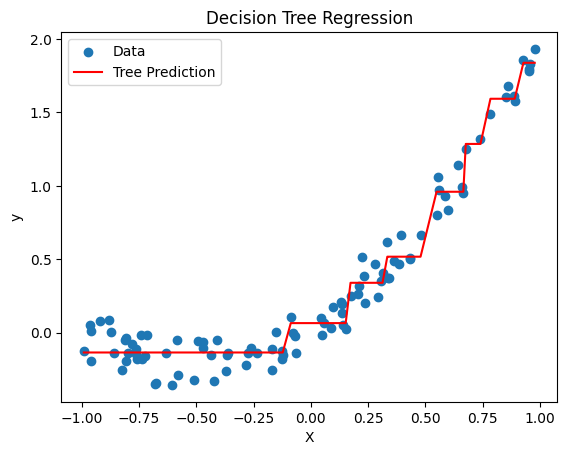

In [18]:
from sklearn.tree import DecisionTreeRegressor

np.random.seed(0)
X_tree = np.sort(2 * np.random.rand(100, 1) - 1, axis=0)
y_tree = X_tree[:, 0]**2 + X_tree[:, 0] + np.random.randn(100) * 0.1

tree_reg = DecisionTreeRegressor(max_depth=3)
tree_reg.fit(X_tree, y_tree)

plt.scatter(X_tree, y_tree, label="Data")
plt.plot(X_tree, tree_reg.predict(X_tree), color="red", label="Tree Prediction")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.title("Decision Tree Regression")
plt.show()


## 17. Random Forest Regression

Random Forest aggregates predictions from multiple decision trees to improve accuracy and control overfitting.

**Assumptions**: No strong distributional assumptions; relies on the law of large numbers.
**Formula**: $\hat{y} = \frac{1}{T}\sum_{t=1}^{T} f_t(x)$, averaging predictions from many trees.
**Loss Function**: Mean Squared Error aggregated over trees.
**Likelihood Function**: Not applicable.
**Goodness-of-Fit Metrics**: R-squared, RMSE, out-of-bag error.
**Residual Analysis**: Difference between actual and averaged predictions.
**Overfitting Risk**: Lower than a single tree due to averaging.
**Convergence Speed**: Training can be parallelized; prediction is fast.
**Optimization Algorithm Used**: Bagging with random feature selection.
**Handling of Outliers**: Outliers have less influence due to averaging.
**Sensitivity to Multicollinearity**: Less sensitive as trees are built on random subsets.
**Sensitivity to Heteroscedasticity**: Can handle non-constant variance better than a single tree.
**Applicability to High-Dimensional Data**: Effective though interpretability may decrease.
**Robustness to Non-Normal Data**: Very robust due to its nonparametric nature.
**Time-Series Applicability**: Applicable after appropriate feature extraction.


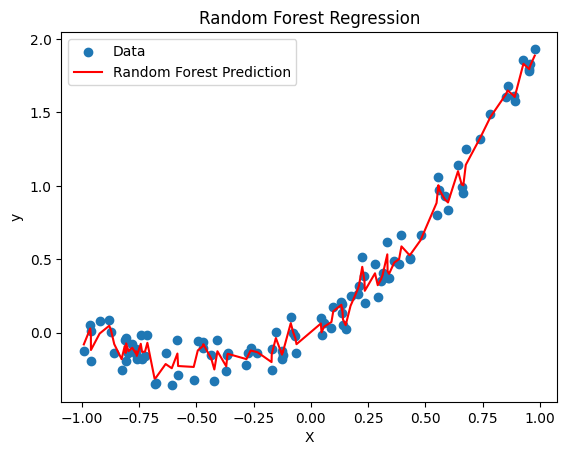

In [19]:
from sklearn.ensemble import RandomForestRegressor

np.random.seed(0)
X_forest = np.sort(2 * np.random.rand(100, 1) - 1, axis=0)
y_forest = X_forest[:, 0]**2 + X_forest[:, 0] + np.random.randn(100) * 0.1

forest_reg = RandomForestRegressor(n_estimators=100, random_state=0)
forest_reg.fit(X_forest, y_forest)

plt.scatter(X_forest, y_forest, label="Data")
plt.plot(X_forest, forest_reg.predict(X_forest), color="red", label="Random Forest Prediction")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.title("Random Forest Regression")
plt.show()


## 18. Support Vector Regression (SVR)

SVR applies support vector machine principles to regression tasks using kernel functions.

**Assumptions**: Data can be mapped to a higher-dimensional space where a linear model is effective.
**Formula**: $y = \langle w, \phi(x) \rangle + b$ with an $\varepsilon$-insensitive loss.
**Loss Function**: $\varepsilon$-insensitive loss function combined with regularization.
**Likelihood Function**: Not explicitly used; based on structural risk minimization.
**Goodness-of-Fit Metrics**: R-squared, RMSE.
**Residual Analysis**: Similar to OLS; residuals are inspected.
**Overfitting Risk**: Controlled by regularization parameter C and kernel choice.
**Convergence Speed**: Can be slower with large datasets due to quadratic programming.
**Optimization Algorithm Used**: Quadratic programming solvers.
**Handling of Outliers**: The $\varepsilon$-insensitive zone reduces the impact of small outliers, but large outliers can affect the fit.
**Sensitivity to Multicollinearity**: Less affected since data is mapped to a high-dimensional space.
**Sensitivity to Heteroscedasticity**: Not explicitly addressed.
**Applicability to High-Dimensional Data**: Computationally intensive for very large datasets.
**Robustness to Non-Normal Data**: Moderate; performance depends on the kernel.
**Time-Series Applicability**: Can be used with appropriate lag features.


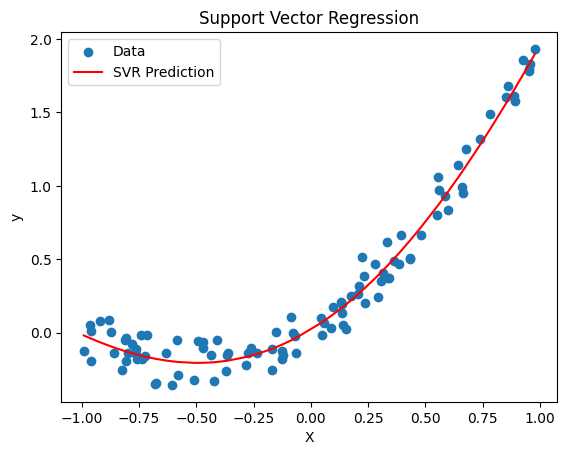

In [20]:
from sklearn.svm import SVR

np.random.seed(0)
X_svr = np.sort(2 * np.random.rand(100, 1) - 1, axis=0)
y_svr = X_svr[:, 0]**2 + X_svr[:, 0] + np.random.randn(100) * 0.1

svr_reg = SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.1)
svr_reg.fit(X_svr, y_svr)

plt.scatter(X_svr, y_svr, label="Data")
plt.plot(X_svr, svr_reg.predict(X_svr), color="red", label="SVR Prediction")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.title("Support Vector Regression")
plt.show()


## 19. Neural Network Regression

We build a neural network regressor using scikit-learn's `MLPRegressor`.

**Assumptions**: Nonlinear relationships can be modeled with layered architectures.
**Formula**: A composition of linear functions and nonlinear activation functions.
**Loss Function**: Squared error for regression tasks.
**Likelihood Function**: Gaussian likelihood when errors are assumed normal.
**Goodness-of-Fit Metrics**: R-squared, RMSE.
**Residual Analysis**: Residuals are inspected similarly to OLS.
**Overfitting Risk**: High if the network is too complex; mitigated by regularization and dropout.
**Convergence Speed**: Can be slow; depends on network depth and learning rate.
**Optimization Algorithm Used**: Stochastic gradient descent variants (e.g., Adam).
**Handling of Outliers**: Can be sensitive unless robust loss functions are used.
**Sensitivity to Multicollinearity**: Not directly affected due to feature learning.
**Sensitivity to Heteroscedasticity**: Not specifically addressed.
**Applicability to High-Dimensional Data**: Well-suited if sufficient data are available.
**Robustness to Non-Normal Data**: Depends on architecture and loss function.
**Time-Series Applicability**: Can be extended to recurrent or convolutional architectures.


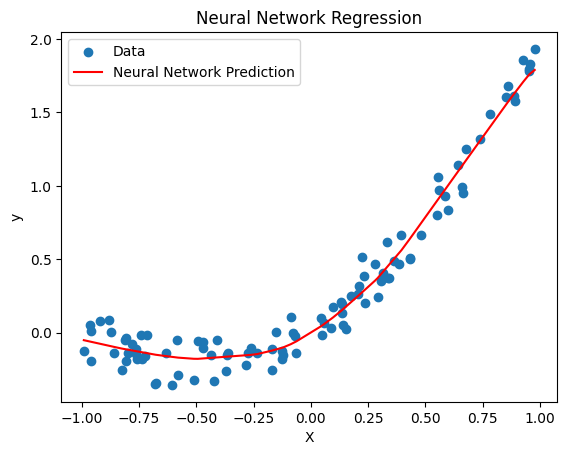

In [21]:
from sklearn.neural_network import MLPRegressor

np.random.seed(0)
X_nn = np.sort(2 * np.random.rand(100, 1) - 1, axis=0)
y_nn = X_nn[:, 0]**2 + X_nn[:, 0] + np.random.randn(100) * 0.1

mlp_reg = MLPRegressor(hidden_layer_sizes=(50, 50), max_iter=1000, random_state=0)
mlp_reg.fit(X_nn, y_nn)

plt.scatter(X_nn, y_nn, label="Data")
plt.plot(X_nn, mlp_reg.predict(X_nn), color="red", label="Neural Network Prediction")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.title("Neural Network Regression")
plt.show()


## 20. Principal Component Regression (PCR)

PCR combines principal component analysis (PCA) with linear regression to address multicollinearity.

**Assumptions**: Predictors can be represented in a lower-dimensional subspace.
**Formula**: $y = \beta_0 + \beta_1 t_1 + \beta_2 t_2 + \cdots$, where $t_i$ are the principal components.
**Loss Function**: Mean Squared Error (MSE) on the principal component scores.
**Likelihood Function**: Gaussian likelihood in the reduced space.
**Goodness-of-Fit Metrics**: R-squared, RMSE, cross-validated error.
**Residual Analysis**: Residuals are analyzed in the context of the principal component model.
**Overfitting Risk**: Lower if the number of components is chosen appropriately.
**Convergence Speed**: Fast once PCA is computed.
**Optimization Algorithm Used**: PCA (eigen decomposition) followed by linear regression.
**Handling of Outliers**: Sensitive if outliers affect the PCA decomposition.
**Sensitivity to Multicollinearity**: Designed to mitigate multicollinearity.
**Sensitivity to Heteroscedasticity**: Inherits issues from linear regression if present.
**Applicability to High-Dimensional Data**: Effective when predictors are highly correlated.
**Robustness to Non-Normal Data**: Moderate; PCA can be sensitive to non-normality.
**Time-Series Applicability**: Can be applied after proper de-trending and seasonal adjustment.


In [22]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

np.random.seed(0)
X_pcr = 2 * np.random.rand(100, 5)
y_pcr = 1 + 2 * X_pcr[:, 0] + 3 * X_pcr[:, 1] + np.random.randn(100)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_pcr)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

lr_pcr = LinearRegression()
lr_pcr.fit(X_pca, y_pcr)
print("PCR Regression Coefficients:", lr_pcr.coef_)


PCR Regression Coefficients: [1.04877726 0.33989459]


## 21. Robust Regression Methods

Robust regression methods reduce the influence of outliers. Here we demonstrate Huber Regression, RANSAC Regression, and Theil–Sen Regression.

### Huber Regression
- **Assumptions**: Linear relationship; errors are symmetric but may contain outliers.
- **Loss Function**: Huber loss (quadratic for small errors, linear for large errors).

### RANSAC Regression
- **Assumptions**: A sufficient proportion of inliers exist in the data.
- **Loss Function**: Squared error on the inlier subset.

### Theil–Sen Regression
- **Assumptions**: Linear relationship; robust to outliers.
- **Estimation**: Slope is estimated as the median of slopes computed from all pairs of points.


In [23]:
from sklearn.linear_model import HuberRegressor, RANSACRegressor, TheilSenRegressor

# Generate synthetic data with outliers
np.random.seed(0)
X_robust = 2 * np.random.rand(100, 1)
y_robust = 4 + 3 * X_robust[:, 0] + np.random.randn(100)
y_robust[::10] += 10  # introduce outliers

# Huber Regression
huber = HuberRegressor()
huber.fit(X_robust, y_robust)
print("Huber Regression Coefficients:", huber.coef_, "Intercept:", huber.intercept_)

# RANSAC Regression
ransac = RANSACRegressor()
ransac.fit(X_robust, y_robust)
print("RANSAC Regression Coefficients:", ransac.estimator_.coef_, "Intercept:", ransac.estimator_.intercept_)

# Theil–Sen Regression
theilsen = TheilSenRegressor()
theilsen.fit(X_robust, y_robust)
print("Theil–Sen Regression Coefficients:", theilsen.coef_, "Intercept:", theilsen.intercept_)


Huber Regression Coefficients: [2.98137058] Intercept: 4.379292064066175
RANSAC Regression Coefficients: [2.82550382] Intercept: 4.219355806545146
Theil–Sen Regression Coefficients: [3.08737568] Intercept: 4.369666247360611


## 22. Partial Least Squares (PLS) Regression

PLS regression projects both the predictors and the response onto a lower-dimensional latent space to handle multicollinearity.

**Assumptions**: Assumes latent variables capture the covariance between predictors and the response.
**Formula**: $y = \beta_0 + \sum_{i=1}^{k} \beta_i t_i$, where $t_i$ are the latent components.
**Loss Function**: Mean Squared Error in the latent space.
**Goodness-of-Fit Metrics**: R-squared, RMSE, cross-validation error.
**Overfitting Risk**: Controlled by selecting the number of components (via cross-validation).


In [24]:
from sklearn.cross_decomposition import PLSRegression

np.random.seed(0)
X_pls = np.random.rand(100, 10)
X_pls[:, 5] = X_pls[:, 0] + 0.1 * np.random.randn(100)
X_pls[:, 6] = X_pls[:, 1] - 0.1 * np.random.randn(100)
y_pls = 3 + 2 * X_pls[:, 0] + 4 * X_pls[:, 1] + np.random.randn(100)

pls = PLSRegression(n_components=2)
pls.fit(X_pls, y_pls)
print("PLS Regression Coefficients:", pls.coef_.flatten())


PLS Regression Coefficients: [ 1.23353729  1.99416099  0.05011557  0.5411282   0.23336079  1.10496841
  1.73560133 -0.19012075  0.46328527  0.20465059]


## 23. Kernel Ridge Regression

Kernel Ridge Regression combines ridge regression with the kernel trick to capture nonlinear relationships.

**Assumptions**: Data can be mapped to a high-dimensional space where a linear model is appropriate.
**Formula**: $y = \sum_{i=1}^{n} \alpha_i K(x, x_i)$, where $K(\cdot,\cdot)$ is a kernel function.
**Loss Function**: Squared error with an L2 penalty on the dual coefficients.
**Goodness-of-Fit Metrics**: R-squared, RMSE.
**Handling of Outliers**: Not specifically robust.
**Time-Series Applicability**: Can be applied if temporal dependencies are incorporated into the kernel.


Kernel Ridge Regression Coefficients (dual coefficients): [ 0.44681094  0.28108982  0.3098702   0.40737197  0.34179461  0.0296387
  0.19537141  0.05898327  0.03840057  0.06531405  0.01519418  0.12382647
  0.03324971 -0.05074443 -0.03733651 -0.06587387  0.0339798  -0.15076603
 -0.112374   -0.24110872 -0.42158971 -0.11008507 -0.09672145 -0.26366471
  0.0326704  -0.34318636 -0.19522603 -0.2192043  -0.0465535  -0.05093676
 -0.17915358 -0.15238528 -0.27335795 -0.37591247 -0.20480768 -0.14555334
 -0.02838017 -0.02050548 -0.16799027 -0.14725097 -0.20895935 -0.23258273
 -0.2471533   0.13306098 -0.09809472 -0.07575129 -0.14181874  0.07675333
 -0.14678368  0.00891152 -0.04388465  0.09964539  0.0249046  -0.02739044
  0.10212171  0.16154268  0.13855742  0.17470156  0.09285085  0.13104719
  0.11025478  0.15080041  0.11370808  0.02961302  0.22609659  0.17312844
  0.05402831  0.26580985  0.12998377  0.22574932  0.29192912  0.22897707
  0.32564492  0.08239442  0.23881305  0.12131826  0.09245248  0.109

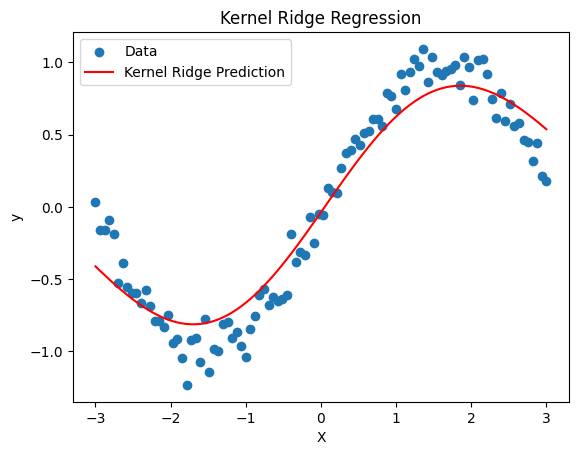

In [25]:
from sklearn.kernel_ridge import KernelRidge

np.random.seed(0)
X_kernel = np.linspace(-3, 3, 100).reshape(-1, 1)
y_kernel = np.sin(X_kernel).ravel() + np.random.randn(100) * 0.1

krr = KernelRidge(alpha=1.0, kernel='rbf', gamma=0.1)
krr.fit(X_kernel, y_kernel)
print("Kernel Ridge Regression Coefficients (dual coefficients):", krr.dual_coef_)

plt.scatter(X_kernel, y_kernel, label="Data")
plt.plot(X_kernel, krr.predict(X_kernel), color="red", label="Kernel Ridge Prediction")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.title("Kernel Ridge Regression")
plt.show()


## 24. Generalized Additive Models (GAMs)

GAMs extend generalized linear models by allowing smooth, nonlinear functions for each predictor. They are useful when the relationship between predictors and the response is complex and nonparametric.

**Assumptions**: Assumes additivity of smooth functions; residuals are independent.
**Formula**: $y = \beta_0 + f_1(x_1) + f_2(x_2) + \cdots + f_p(x_p)$, where $f_i$ are smooth functions (e.g., splines).
**Loss Function**: Depends on the response distribution; for Gaussian GAM, squared error loss is used.
**Goodness-of-Fit Metrics**: Deviance, AIC, GCV, R-squared.
**Overfitting Risk**: Controlled by smoothness penalties.
**Convergence Speed**: Generally slower due to iterative backfitting.
**Optimization Algorithm Used**: Backfitting algorithm with penalized splines.
**Handling of Outliers**: Not inherently robust; can be modified with robust loss functions.
**Time-Series Applicability**: Can be applied if time is included as a predictor or via specialized GAMs for time-series.


GAM summary:
LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                      5.4912
Link Function:                     IdentityLink Log Likelihood:                                     4.4068
Number of Samples:                          100 AIC:                                                4.1689
                                                AICc:                                               5.2201
                                                GCV:                                                0.0628
                                                Scale:                                               0.238
                                                Pseudo R-Squared:                                   0.8972
Feature Function        

/var/folders/_8/113ryn811zx2cnw99n36jht00000gn/T/ipykernel_86602/2587830503.py:11: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  print(gam.summary())


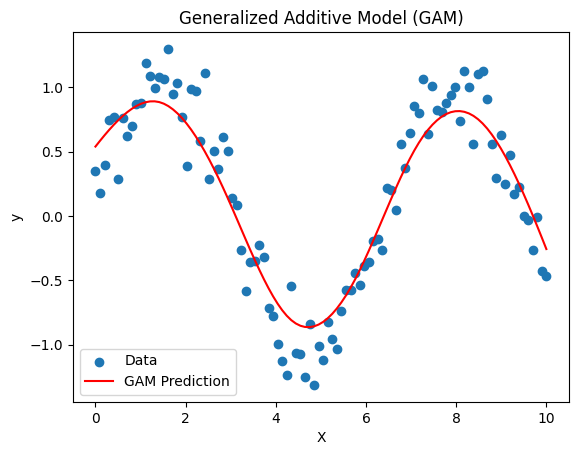

In [26]:
from pygam import LinearGAM, s
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
X_gam = np.linspace(0, 10, 100).reshape(-1, 1)
y_gam = np.sin(X_gam).ravel() + np.random.randn(100) * 0.2

gam = LinearGAM(s(0, n_splines=10)).fit(X_gam, y_gam)
print("GAM summary:")
print(gam.summary())

XX = gam.generate_X_grid(term=0)
plt.scatter(X_gam, y_gam, label='Data')
plt.plot(XX, gam.predict(XX), color='red', label='GAM Prediction')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.title('Generalized Additive Model (GAM)')
plt.show()

# Conclusion

This notebook has demonstrated a wide range of regression techniques — from simple linear models to advanced methods including Cox regression, robust regression (Huber, RANSAC, Theil–Sen), PLS regression, kernel ridge regression, and generalized additive models (GAMs).

For each method, I provided code examples and discussed key aspects such as assumptions, formulas, loss functions, likelihood functions, goodness-of-fit metrics, residual analysis, overfitting risk, convergence speed, optimization algorithms, handling of outliers, sensitivity to multicollinearity and heteroscedasticity, applicability to high-dimensional data, robustness to non-normal data, and time-series applicability.

For further details on these techniques, consider reading:
- *The Elements of Statistical Learning* (Hastie, Tibshirani, & Friedman, 2009)
- *An Introduction to Statistical Learning* (James et al., 2013)